# Model Training — Teacher–Student Knowledge Distillation

This notebook implements the full pipeline:

| Section | Description |
|---|---|
| **D** | Teacher Model — Wav2Vec2-XLSR + AASIST + OC-Softmax |
| **E** | Teacher Soft Predictions |
| **F** | Student Model — Frozen Wav2Vec2-XLSR + AASIST-L |
| **G** | Knowledge Distillation Training |
| **H** | Final Prediction |
| **I** | Evaluation — EER, min-tDCF, Accuracy, Precision, Recall, F1, Confusion Matrix |

## 1. Install Dependencies

In [1]:
import sys

# ── Detect environment ────────────────────────────────────────────────────────
try:
    from google.colab import drive
    IN_COLAB = True
    drive.mount('/content/drive')
    print('Running on Google Colab | Drive mounted.')
except ImportError:
    IN_COLAB = False
    print('Running locally.')

# ── Install dependencies ──────────────────────────────────────────────────────
# Colab already has torch/numpy/scipy/sklearn/matplotlib/seaborn.
# Only soundfile and transformers may need installing.
if IN_COLAB:
    import subprocess
    subprocess.run(
        ['pip', 'install', 'soundfile', 'transformers', 'torchaudio', '-q'],
        check=True
    )
    print('Dependencies ready.')

Running locally.


## 2. Imports

In [2]:
import os
import numpy as np
import soundfile as sf
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import Wav2Vec2Model, Wav2Vec2FeatureExtractor
from pathlib import Path
from tqdm import tqdm
from scipy.optimize import brentq
from scipy.interpolate import interp1d
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score,
                              confusion_matrix, roc_curve)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Device detection (CPU locally, GPU on Colab) ─────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
if device.type == 'cuda':
    print(f'  GPU   : {torch.cuda.get_device_name(0)}')
    print(f'  VRAM  : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device : cpu


In [3]:
# ── SMOKE TEST — runs in ~5 seconds, no data files needed ────────────────────
# Set RUN_SMOKE_TEST = True to verify the full pipeline with dummy data.
# Set it back to False before running the real training.
RUN_SMOKE_TEST = False

if RUN_SMOKE_TEST:
    import torch, torch.nn.functional as F
    from torch.utils.data import DataLoader, TensorDataset

    _B, _T, _D = 4, 200, 1024   # batch, frames, wav2vec2 dim
    _device = torch.device('cpu')

    # ── 1. Dummy models ───────────────────────────────────────────────────────
    # Import inline so this cell can run before later cells define the classes
    import torch.nn as nn

    class _TBackend(nn.Module):
        def __init__(self, d=256, h=8):
            super().__init__()
            self.proj = nn.Linear(1024, d)
            el = nn.TransformerEncoderLayer(d, h, d*2, batch_first=True)
            self.tr   = nn.TransformerEncoder(el, 2)
            self.pool = nn.Linear(d, 1)
            self.cls  = nn.Linear(d, 2)
        def forward(self, x, key_padding_mask=None):
            x = self.proj(x)
            x = self.tr(x, src_key_padding_mask=key_padding_mask)
            a = self.pool(x)
            if key_padding_mask is not None:
                a = a.masked_fill(key_padding_mask.unsqueeze(-1), float('-inf'))
            x = (x * a.softmax(1)).sum(1)
            return self.cls(x)

    t_model = _TBackend(256, 8).to(_device)
    s_model = _TBackend(128, 4).to(_device)

    # ── 2. Dummy batch ────────────────────────────────────────────────────────
    feat   = torch.randn(_B, _T, _D)
    labels = torch.randint(0, 2, (_B,))
    mask   = torch.zeros(_B, _T, dtype=torch.bool)
    mask[:, 150:] = True   # last 50 frames are "padding"

    # ── 3. Teacher forward + OC-Softmax-like loss ─────────────────────────────
    t_logits = t_model(feat, key_padding_mask=mask)
    t_loss   = F.cross_entropy(t_logits, labels)
    t_loss.backward()
    print(f'[SMOKE] Teacher forward OK  | loss={t_loss.item():.4f} | logits shape={tuple(t_logits.shape)}')

    # ── 4. Soft predictions ───────────────────────────────────────────────────
    with torch.no_grad():
        soft = F.softmax(t_model(feat, key_padding_mask=mask) / 3.0, dim=1)
    print(f'[SMOKE] Soft predictions OK | shape={tuple(soft.shape)} | sum~1: {soft.sum(1).mean():.4f}')

    # ── 5. Student KD forward ─────────────────────────────────────────────────
    s_logits  = s_model(feat, key_padding_mask=mask)
    ce_loss   = F.cross_entropy(s_logits, labels)
    kd_loss   = F.kl_div(F.log_softmax(s_logits / 3.0, dim=1), soft, reduction='batchmean') * 9
    total     = 0.5 * ce_loss + 0.5 * kd_loss
    total.backward()
    print(f'[SMOKE] Student KD forward OK | loss={total.item():.4f}')

    # ── 6. Mask correctness check ─────────────────────────────────────────────
    no_mask_logits   = t_model(feat, key_padding_mask=None)
    with_mask_logits = t_model(feat, key_padding_mask=mask)
    assert not torch.allclose(no_mask_logits, with_mask_logits), \
        'Mask has no effect — something is wrong!'
    print('[SMOKE] Mask changes output as expected ✓')

    print('\n[SMOKE TEST PASSED] — all pipeline stages work correctly.')
    print('Set RUN_SMOKE_TEST = False and run the real training.')
else:
    print('Smoke test skipped. Set RUN_SMOKE_TEST = True to run it.')

Smoke test skipped. Set RUN_SMOKE_TEST = True to run it.


## 3. Configuration

Edit the paths below to match your project structure.

In [4]:
# ── Paths ────────────────────────────────────────────────────────────────────
if IN_COLAB:
    _BASE            = Path('/content/drive/MyDrive/ASVspoof2019')
    AUGMENTED_DIR    = _BASE / 'data/augmented/LA'
    PREPROCESSED_DIR = _BASE / 'data/preprocessed/LA'
    PROTOCOL_DIR     = _BASE / 'data/raw/LA/ASVspoof2019_LA_cm_protocols'
    RAW_DIR          = _BASE / 'data/raw/LA'
    FEATURE_DIR      = Path('/content/data/features')   # local disk (~95 GB — too large for Drive)
    MODEL_DIR        = _BASE / 'models'
else:
    AUGMENTED_DIR    = Path('../data/augmented/LA')
    PREPROCESSED_DIR = Path('../data/preprocessed/LA')
    PROTOCOL_DIR     = Path('../data/raw/LA/ASVspoof2019_LA_cm_protocols')
    RAW_DIR          = Path('../data/raw/LA')
    FEATURE_DIR      = Path('../data/features')
    MODEL_DIR        = Path('../models')

FEATURE_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# ── Audio ────────────────────────────────────────────────────────────────────
SAMPLE_RATE  = 16000
MAX_SAMPLES  = 64600      # 4.04 s @ 16 kHz — standard in ASVspoof anti-spoofing

# ── Model ────────────────────────────────────────────────────────────────────
WAV2VEC2_MODEL   = 'facebook/wav2vec2-large-xlsr-53'
WAV2VEC2_DIM     = 1024   # output feature dimension of Wav2Vec2-XLSR

# ── Training ─────────────────────────────────────────────────────────────────
BATCH_SIZE       = 16 if device.type == 'cuda' else 4
TEACHER_EPOCHS   = 10
STUDENT_EPOCHS   = 10
LEARNING_RATE    = 1e-4
KD_TEMPERATURE   = 3.0    # softens teacher predictions
KD_ALPHA         = 0.5    # weight: 0.5 * CE + 0.5 * KD loss

print('Configuration set.')
print(f'  Augmented   : {AUGMENTED_DIR}')
print(f'  Preprocessed: {PREPROCESSED_DIR}')
print(f'  Features    : {FEATURE_DIR}')
print(f'  Models      : {MODEL_DIR}')
print(f'  Batch size  : {BATCH_SIZE}  |  Teacher epochs: {TEACHER_EPOCHS}  |  Student epochs: {STUDENT_EPOCHS}')

Configuration set.
  Augmented   : ../data/augmented/LA
  Preprocessed: ../data/preprocessed/LA
  Features    : ../data/features
  Models      : ../models
  Batch size  : 4  |  Teacher epochs: 10  |  Student epochs: 10


## 4. Protocol Parsing

Parse the ASVspoof2019 protocol files to get filenames and labels.

Protocol format: `speaker_id  filename  -  attack_type  label`

In [5]:
def parse_protocol(protocol_path):
    """
    Returns a dict: {filename: label}
    label → 1 = bonafide, 0 = spoof
    """
    data = {}
    with open(protocol_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            filename = parts[1]                        # e.g. LA_T_1000137
            label    = 1 if parts[4] == 'bonafide' else 0
            data[filename] = label
    return data


train_labels = parse_protocol(PROTOCOL_DIR / 'ASVspoof2019.LA.cm.train.trn.txt')
dev_labels   = parse_protocol(PROTOCOL_DIR / 'ASVspoof2019.LA.cm.dev.trl.txt')
eval_labels  = parse_protocol(PROTOCOL_DIR / 'ASVspoof2019.LA.cm.eval.trl.txt')

print(f'Train : {len(train_labels)} files')
print(f'Dev   : {len(dev_labels)}   files')
print(f'Eval  : {len(eval_labels)}  files')
print(f'  Bonafide (train): {sum(v for v in train_labels.values())}')
print(f'  Spoof    (train): {sum(1-v for v in train_labels.values())}')

# ── Class weights to counter spoof:bonafide imbalance (~9:1 in full dataset) ─
# Formula: w_c = N / (C * n_c)  — same as sklearn class_weight='balanced'
_n_bonafide = sum(v for v in train_labels.values())
_n_spoof    = len(train_labels) - _n_bonafide
_n_total    = len(train_labels)
ce_weight   = torch.tensor(
    [_n_total / (2 * max(_n_spoof, 1)),
     _n_total / (2 * max(_n_bonafide, 1))],
    dtype=torch.float32, device=device
)
print(f'\nCE class weights — spoof: {ce_weight[0]:.3f}, bonafide: {ce_weight[1]:.3f}')

Train : 25380 files
Dev   : 24844   files
Eval  : 71237  files
  Bonafide (train): 2580
  Spoof    (train): 22800

CE class weights — spoof: 0.557, bonafide: 4.919


## 5. Feature Extraction — Wav2Vec2-XLSR

Wav2Vec2-XLSR is used as the **front-end** for both teacher and student.
Features are pre-extracted and saved to disk to avoid re-running the large model every epoch.

> This step is slow on CPU. Run once and skip on subsequent runs.

In [6]:
def load_audio(path, max_samples=MAX_SAMPLES):
    """Load and pad/truncate audio to fixed length."""
    x, sr = sf.read(str(path), dtype='float32')
    if x.ndim > 1:
        x = x.mean(axis=1)
    if len(x) > max_samples:
        x = x[:max_samples]
    else:
        x = np.pad(x, (0, max_samples - len(x)))
    return x


def extract_and_save_features(audio_dir, label_dict, split_name, wav2vec2, processor,
                               raw_dir=None):
    """
    Extract Wav2Vec2 features for all files in a split and save as .npy.
    Also saves {fname}_len.npy (original pre-padding length) used to build padding masks.
    raw_dir: path to raw FLAC dir for true original lengths (dev/eval).
             Pass None for augmented train (entire signal treated as valid).
    Skips files already extracted.
    """
    save_dir = FEATURE_DIR / split_name
    save_dir.mkdir(parents=True, exist_ok=True)

    wav2vec2.eval()
    filenames = list(label_dict.keys())

    for fname in tqdm(filenames, desc=f'Extracting {split_name}'):
        out_path = save_dir / f'{fname}.npy'
        len_path = save_dir / f'{fname}_len.npy'
        if out_path.exists() and len_path.exists():
            continue

        audio_path = audio_dir / 'flac' / f'{fname}.flac'
        if not audio_path.exists():
            continue

        if not out_path.exists():
            audio  = load_audio(audio_path)
            inputs = processor(audio, sampling_rate=SAMPLE_RATE,
                               return_tensors='pt', padding=True)
            with torch.no_grad():
                features = wav2vec2(**inputs).last_hidden_state  # [1, T, 1024]
            np.save(str(out_path), features.squeeze(0).numpy())  # [T, 1024]

        if not len_path.exists():
            if raw_dir is not None:
                raw_path = raw_dir / 'flac' / f'{fname}.flac'
                orig_len = min(sf.info(str(raw_path)).frames, MAX_SAMPLES) \
                           if raw_path.exists() else MAX_SAMPLES
            else:
                orig_len = MAX_SAMPLES   # augmented train: whole signal is valid
            np.save(str(len_path), np.array(orig_len, dtype=np.int32))

    print(f'{split_name} features saved to {save_dir}')

In [7]:
# Load Wav2Vec2-XLSR (shared by teacher and student)
# Wav2Vec2FeatureExtractor handles audio preprocessing only (no tokenizer needed)
print('Loading Wav2Vec2-XLSR...')
processor = Wav2Vec2FeatureExtractor.from_pretrained(WAV2VEC2_MODEL)
wav2vec2  = Wav2Vec2Model.from_pretrained(WAV2VEC2_MODEL)
wav2vec2.eval()
print('Wav2Vec2-XLSR loaded.')

Loading Wav2Vec2-XLSR...


Loading weights:   0%|          | 0/422 [00:00<?, ?it/s]

[transformers] Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-large-xlsr-53
Key                          | Status     |  | 
-----------------------------+------------+--+-
project_hid.weight           | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Wav2Vec2-XLSR loaded.


In [8]:
# Extract features for all splits
# Train uses Augmented data; Dev and Eval use Preprocessed (clean)
# RAW_DIR is used only for sf.info() header reads (original lengths) — not full audio loads
extract_and_save_features(
    AUGMENTED_DIR    / 'ASVspoof2019_LA_train', train_labels, 'train', wav2vec2, processor,
    raw_dir=None)   # augmented: entire 64600-sample signal is valid

extract_and_save_features(
    PREPROCESSED_DIR / 'ASVspoof2019_LA_dev',  dev_labels,   'dev',   wav2vec2, processor,
    raw_dir=RAW_DIR  / 'ASVspoof2019_LA_dev')

extract_and_save_features(
    PREPROCESSED_DIR / 'ASVspoof2019_LA_eval', eval_labels,  'eval',  wav2vec2, processor,
    raw_dir=RAW_DIR  / 'ASVspoof2019_LA_eval')

Extracting train:   4%|▍         | 1060/25380 [06:57<2:39:34,  2.54it/s]


KeyboardInterrupt: 

## 6. Dataset

In [ ]:
WAV2VEC2_STRIDE = 320  # conv downsampling factor of wav2vec2-large feature extractor

class ASVspoofDataset(Dataset):
    """
    Loads pre-extracted Wav2Vec2 features and labels.
    Optionally loads teacher soft predictions for KD training.
    """
    def __init__(self, split, label_dict, soft_preds=None):
        self.feature_dir = FEATURE_DIR / split
        self.soft_preds  = soft_preds

        self.samples = [
            (fname, label)
            for fname, label in label_dict.items()
            if (self.feature_dir / f'{fname}.npy').exists()
        ]
        print(f'{split}: {len(self.samples)} samples loaded')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        fname, label = self.samples[idx]
        feat = np.load(str(self.feature_dir / f'{fname}.npy'))  # [T, 1024]

        T = 200
        if feat.shape[0] >= T:
            feat = feat[:T]
        else:
            pad = np.zeros((T - feat.shape[0], feat.shape[1]), dtype=np.float32)
            feat = np.concatenate([feat, pad], axis=0)

        # Padding mask: True = padding frame (Transformer ignores these positions)
        len_path = self.feature_dir / f'{fname}_len.npy'
        if len_path.exists():
            orig_len  = int(np.load(str(len_path)))
            num_valid = min(orig_len // WAV2VEC2_STRIDE, T)
        else:
            num_valid = T   # assume fully valid if length file missing
        key_padding_mask = np.arange(T) >= num_valid   # [T] bool

        item = {
            'feature'         : torch.tensor(feat, dtype=torch.float32),
            'label'           : torch.tensor(label, dtype=torch.long),
            'filename'        : fname,
            'key_padding_mask': torch.tensor(key_padding_mask, dtype=torch.bool),
        }

        if self.soft_preds and fname in self.soft_preds:
            item['soft_pred'] = torch.tensor(self.soft_preds[fname], dtype=torch.float32)

        return item


train_dataset = ASVspoofDataset('train', train_labels)
dev_dataset   = ASVspoofDataset('dev',   dev_labels)
eval_dataset  = ASVspoofDataset('eval',  eval_labels)

train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
dev_loader    = DataLoader(dev_dataset,   batch_size=BATCH_SIZE, shuffle=False)
eval_loader   = DataLoader(eval_dataset,  batch_size=BATCH_SIZE, shuffle=False)

train: 50 samples loaded
dev: 20 samples loaded
eval: 20 samples loaded


In [ ]:
def compute_eer(bonafide_scores, spoof_scores):
    """
    Equal Error Rate — threshold where FAR == FRR.
    Returns EER as a percentage.
    """
    scores = np.concatenate([bonafide_scores, spoof_scores])
    labels = np.concatenate([np.ones(len(bonafide_scores)),
                              np.zeros(len(spoof_scores))])
    fpr, tpr, _ = roc_curve(labels, scores, pos_label=1)
    fnr         = 1 - tpr
    eer         = brentq(lambda x: 1. - x - interp1d(fpr, tpr)(x), 0., 1.)
    return eer * 100, fpr, tpr


def compute_min_tdcf(bonafide_scores, spoof_scores,
                      p_spoof=0.05, c_cm_miss=1.0, c_cm_fa=10.0):
    """
    Simplified min-tDCF for standalone CM system.
    Based on ASVspoof2019 evaluation protocol.
    """
    scores = np.concatenate([bonafide_scores, spoof_scores])
    labels = np.concatenate([np.ones(len(bonafide_scores)),
                              np.zeros(len(spoof_scores))])

    fpr, tpr, thresholds = roc_curve(labels, scores, pos_label=1)
    fnr = 1 - tpr

    # tDCF = C_miss * P_spoof * FNR + C_fa * (1-P_spoof) * FPR
    tdcf = (c_cm_miss * p_spoof * fnr) + (c_cm_fa * (1 - p_spoof) * fpr)

    # Normalise by the minimum cost of a trivial system
    tdcf_norm = tdcf / min(c_cm_miss * p_spoof, c_cm_fa * (1 - p_spoof))

    return float(np.min(tdcf_norm))


print('compute_eer() and compute_min_tdcf() defined.')


compute_eer() and compute_min_tdcf() defined.


## D. Teacher Model — Transformer Backend (AASIST-style)

The teacher back-end classifies audio as bona fide or spoof by learning **temporal spoofing patterns** from Wav2Vec2-XLSR features using a Transformer encoder with attention pooling.

> **Architecture note:** This is a Transformer-based classifier (Linear projection → 2× Transformer layers → Attention pooling → Classifier), which approximates the role of the AASIST back-end described in the report. The full AASIST uses graph attention networks on raw waveform; this implementation operates on pre-extracted Wav2Vec2 features.

In [ ]:
class AASISTBackend(nn.Module):
    """
    Teacher back-end classifier (AASIST-style Transformer).
    Input : [batch, T, 1024]  Wav2Vec2-XLSR features
    Output: [batch, 2]        logits (bona fide / spoof)

    Architecture
    ------------
    Linear projection (1024→256) → 2× TransformerEncoderLayer (8 heads)
    → Attention pooling over time → Classifier (256→128→2)

    Inspired by the AASIST paper (Jung et al., ICASSP 2022), adapted to
    operate on Wav2Vec2 features rather than raw waveform.
    """
    def __init__(self, input_dim=1024, d_model=256, num_heads=8,
                 ff_dim=512, num_layers=2, dropout=0.1):
        super().__init__()

        self.proj = nn.Linear(input_dim, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=num_heads,
            dim_feedforward=ff_dim, dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.attn_pool = nn.Linear(d_model, 1)

        self.classifier = nn.Sequential(
            nn.Linear(d_model, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 2)
        )

    def forward(self, x, key_padding_mask=None):
        # x: [batch, T, 1024]
        x = self.proj(x)                                                   # [batch, T, d_model]
        x = self.transformer(x, src_key_padding_mask=key_padding_mask)    # [batch, T, d_model]

        # Attention pooling — mask padding positions before softmax
        attn_logits = self.attn_pool(x)                                    # [batch, T, 1]
        if key_padding_mask is not None:
            attn_logits = attn_logits.masked_fill(
                key_padding_mask.unsqueeze(-1), float('-inf'))
        weights = torch.softmax(attn_logits, dim=1)                        # [batch, T, 1]
        x = (x * weights).sum(dim=1)                                       # [batch, d_model]

        return self.classifier(x)                                          # [batch, 2]


teacher_model = AASISTBackend().to(device)
total_params  = sum(p.numel() for p in teacher_model.parameters())
print(f'Teacher parameters: {total_params:,}')

Teacher parameters: 1,350,019


## 7. OC-Softmax Loss

OC-Softmax pulls **bona fide** samples toward a learned centre and pushes **spoof** samples away, improving separation between real and fake speech.

In [ ]:
class OCSoftmaxLoss(nn.Module):
    """
    One-Class Softmax Loss for anti-spoofing.
    Ref: Zhang et al., One-class Learning Towards Synthetic Voice Spoofing Detection.

    - r_real : target radius for bona fide samples (pull inward)
    - r_fake : target radius for spoof samples    (push outward)
    - alpha  : scaling factor
    """
    def __init__(self, feat_dim=2, r_real=0.9, r_fake=0.5, alpha=20.0):
        super().__init__()
        self.r_real  = r_real
        self.r_fake  = r_fake
        self.alpha   = alpha
        self.center  = nn.Parameter(torch.randn(feat_dim))

    def forward(self, logits, labels):
        """
        logits : [batch, 2]
        labels : [batch]  — 1 = bonafide, 0 = spoof
        """
        # Normalise logits and centre
        logits_norm = F.normalize(logits, dim=1)
        center_norm = F.normalize(self.center.unsqueeze(0), dim=1)

        # Cosine similarity to centre
        cos_sim = (logits_norm * center_norm).sum(dim=1)  # [batch]

        # OC-Softmax margin loss
        loss_real = torch.clamp(self.r_real - cos_sim, min=0)[labels == 1].mean()
        loss_fake = torch.clamp(cos_sim - self.r_fake, min=0)[labels == 0].mean()

        # Handle edge case: all samples in batch are same class.
        # Use logits.new_tensor() to keep the fallback on the same device as input.
        if torch.isnan(loss_real): loss_real = logits.new_tensor(0.0)
        if torch.isnan(loss_fake): loss_fake = logits.new_tensor(0.0)

        return self.alpha * (loss_real + loss_fake)


oc_softmax = OCSoftmaxLoss(feat_dim=2).to(device)
print('OC-Softmax loss defined.')

## D. Train Teacher Model

In [ ]:
teacher_optimizer = torch.optim.Adam(
    list(teacher_model.parameters()) + list(oc_softmax.parameters()),
    lr=LEARNING_RATE
)

teacher_history = {'train_loss': [], 'dev_loss': [], 'dev_acc': []}

# ── Resume from checkpoint if one exists ─────────────────────────────────────
teacher_ckpts     = sorted(MODEL_DIR.glob('teacher_epoch_*.pt'))
teacher_start_epoch = 1
if teacher_ckpts:
    latest = teacher_ckpts[-1]
    ckpt   = torch.load(str(latest), map_location=device)
    teacher_model.load_state_dict(ckpt['model_state_dict'])
    teacher_optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    oc_softmax.load_state_dict(ckpt['oc_softmax_state_dict'])
    teacher_history     = ckpt.get('history', teacher_history)
    teacher_start_epoch = ckpt['epoch'] + 1
    print(f'Resuming teacher training from epoch {teacher_start_epoch} '
          f'(loaded {latest.name})')
else:
    print('Starting teacher training from epoch 1.')

if teacher_start_epoch > TEACHER_EPOCHS:
    print('Teacher training already complete — skipping.')
else:
    print('Training Teacher Model...')
    for epoch in range(teacher_start_epoch, TEACHER_EPOCHS + 1):

        # ── Train ────────────────────────────────────────────────────────────
        teacher_model.train()
        train_loss = 0.0

        for batch in tqdm(train_loader, desc=f'Epoch {epoch}/{TEACHER_EPOCHS} [Teacher Train]'):
            features = batch['feature'].to(device)
            labels   = batch['label'].to(device)
            mask     = batch['key_padding_mask'].to(device)

            teacher_optimizer.zero_grad()
            logits = teacher_model(features, key_padding_mask=mask)

            loss = oc_softmax(logits, labels) + F.cross_entropy(logits, labels, weight=ce_weight)
            loss.backward()
            teacher_optimizer.step()
            train_loss += loss.item()

        train_loss /= len(train_loader)

        # ── Validate ─────────────────────────────────────────────────────────
        teacher_model.eval()
        dev_loss, correct, total = 0.0, 0, 0

        with torch.no_grad():
            for batch in dev_loader:
                features = batch['feature'].to(device)
                labels   = batch['label'].to(device)
                mask     = batch['key_padding_mask'].to(device)
                logits   = teacher_model(features, key_padding_mask=mask)
                dev_loss += F.cross_entropy(logits, labels, weight=ce_weight).item()
                preds     = logits.argmax(dim=1)
                correct  += (preds == labels).sum().item()
                total    += labels.size(0)

        dev_loss /= len(dev_loader)
        dev_acc   = correct / total

        teacher_history['train_loss'].append(train_loss)
        teacher_history['dev_loss'].append(dev_loss)
        teacher_history['dev_acc'].append(dev_acc)

        print(f'Epoch {epoch:02d} | Train Loss: {train_loss:.4f} | '
              f'Dev Loss: {dev_loss:.4f} | Dev Acc: {dev_acc:.4f}')

        # ── Per-epoch checkpoint ──────────────────────────────────────────────
        torch.save({
            'epoch'                : epoch,
            'model_state_dict'     : teacher_model.state_dict(),
            'optimizer_state_dict' : teacher_optimizer.state_dict(),
            'oc_softmax_state_dict': oc_softmax.state_dict(),
            'history'              : teacher_history,
        }, str(MODEL_DIR / f'teacher_epoch_{epoch:02d}.pt'))

    print('\nTeacher training complete.')

## E. Teacher Soft Predictions

The trained teacher generates **soft predictions** on the training set. These show confidence per class (e.g. `[0.08, 0.92]`) and are used to guide student training.

In [ ]:
soft_pred_path = MODEL_DIR / 'soft_predictions.pt'

if soft_pred_path.exists():
    # Load previously saved soft predictions — skips regeneration on resume
    raw = torch.load(str(soft_pred_path), map_location='cpu')
    soft_predictions = {k: (v.numpy() if hasattr(v, 'numpy') else v) for k, v in raw.items()}
    print(f'Loaded existing soft predictions ({len(soft_predictions)} samples).')
else:
    teacher_model.eval()
    soft_predictions = {}
    temp_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)

    with torch.no_grad():
        for batch in tqdm(temp_loader, desc='Generating soft predictions'):
            features   = batch['feature'].to(device)
            mask       = batch['key_padding_mask'].to(device)
            filenames  = batch['filename']
            logits     = teacher_model(features, key_padding_mask=mask)
            soft_preds = F.softmax(logits / KD_TEMPERATURE, dim=1)
            for fname, pred in zip(filenames, soft_preds):
                soft_predictions[fname] = pred.cpu().numpy()

    # Save to MODEL_DIR so it survives a session restart
    torch.save(soft_predictions, str(soft_pred_path))
    print(f'Soft predictions generated and saved ({len(soft_predictions)} samples).')

sample_key = list(soft_predictions.keys())[0]
print(f'  Example — {sample_key}: bonafide={soft_predictions[sample_key][1]:.3f}, '
      f'spoof={soft_predictions[sample_key][0]:.3f}')

## D. Teacher Evaluation on Eval Set

Evaluate the **trained teacher** on the held-out eval set using the same metrics as the student.
This allows a direct teacher vs student comparison after knowledge distillation.

In [ ]:
teacher_model.eval()

t_all_preds, t_all_labels        = [], []
t_bonafide_scores, t_spoof_scores = [], []

with torch.no_grad():
    for batch in tqdm(eval_loader, desc='Teacher: Evaluating on Eval Set'):
        features = batch['feature'].to(device)
        labels   = batch['label'].to(device)
        mask     = batch['key_padding_mask'].to(device)

        logits = teacher_model(features, key_padding_mask=mask)
        probs  = F.softmax(logits, dim=1)
        preds  = logits.argmax(dim=1)

        bonafide_score = probs[:, 1].cpu().numpy()

        for score, label in zip(bonafide_score, labels.cpu().numpy()):
            if label == 1:
                t_bonafide_scores.append(score)
            else:
                t_spoof_scores.append(score)

        t_all_preds.extend(preds.cpu().numpy())
        t_all_labels.extend(labels.cpu().numpy())

t_all_preds  = np.array(t_all_preds)
t_all_labels = np.array(t_all_labels)

teacher_eer, t_fpr, t_tpr = compute_eer(
    np.array(t_bonafide_scores), np.array(t_spoof_scores))
teacher_min_tdcf  = compute_min_tdcf(
    np.array(t_bonafide_scores), np.array(t_spoof_scores))
teacher_accuracy  = accuracy_score(t_all_labels, t_all_preds)
teacher_precision = precision_score(t_all_labels, t_all_preds, zero_division=0)
teacher_recall    = recall_score(t_all_labels, t_all_preds, zero_division=0)
teacher_f1        = f1_score(t_all_labels, t_all_preds, zero_division=0)

print('=' * 50)
print('    TEACHER EVALUATION RESULTS (Eval Set)')
print('=' * 50)
print(f'  EER          : {teacher_eer:.2f}%')
print(f'  min-tDCF     : {teacher_min_tdcf:.4f}')
print(f'  Accuracy     : {teacher_accuracy:.4f}')
print(f'  Precision    : {teacher_precision:.4f}')
print(f'  Recall       : {teacher_recall:.4f}')
print(f'  F1-Score     : {teacher_f1:.4f}')
print('=' * 50)

Teacher: Evaluating on Eval Set: 100%|██████████| 5/5 [00:00<00:00, 44.55it/s]

    TEACHER EVALUATION RESULTS (Eval Set)
  EER          : 43.75%
  min-tDCF     : 0.7500
  Accuracy     : 0.8000
  Precision    : 0.0000
  Recall       : 0.0000
  F1-Score     : 0.0000


## F. Student Model — Lightweight Transformer Backend (AASIST-L-style)

The student is a **compressed** version of the teacher (half the dimensions, half the heads). The Wav2Vec2-XLSR front-end is **frozen** — only the lightweight back-end is trained via knowledge distillation.

In [ ]:
class AASISTLBackend(nn.Module):
    """
    Student back-end classifier (AASIST-L-style Transformer, lightweight).
    Same architecture as AASISTBackend with reduced dimensions:
      d_model : 256 → 128
      heads   : 8   → 4
      ff_dim  : 512 → 256
    This gives ~3-4× fewer parameters than the teacher.
    """
    def __init__(self, input_dim=1024, d_model=128, num_heads=4,
                 ff_dim=256, num_layers=2, dropout=0.1):
        super().__init__()

        self.proj = nn.Linear(input_dim, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=num_heads,
            dim_feedforward=ff_dim, dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.attn_pool = nn.Linear(d_model, 1)

        self.classifier = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 2)
        )

    def forward(self, x, key_padding_mask=None):
        x           = self.proj(x)
        x           = self.transformer(x, src_key_padding_mask=key_padding_mask)
        attn_logits = self.attn_pool(x)                                    # [batch, T, 1]
        if key_padding_mask is not None:
            attn_logits = attn_logits.masked_fill(
                key_padding_mask.unsqueeze(-1), float('-inf'))
        weights = torch.softmax(attn_logits, dim=1)
        x       = (x * weights).sum(dim=1)
        return self.classifier(x)


student_model = AASISTLBackend().to(device)

teacher_params = sum(p.numel() for p in teacher_model.parameters())
student_params = sum(p.numel() for p in student_model.parameters())

print(f'Teacher parameters : {teacher_params:,}')
print(f'Student parameters : {student_params:,}')
print(f'Compression ratio  : {teacher_params / student_params:.1f}×')
print('Wav2Vec2-XLSR front-end is frozen (shared, not fine-tuned during student training)')

Teacher parameters : 1,350,019
Student parameters : 404,675
Compression ratio  : 3.3×
Wav2Vec2-XLSR front-end is frozen (shared, not fine-tuned during student training)


## G. Knowledge Distillation Loss

The student learns from two signals:
- **Hard label loss** (CE): learn the correct class
- **KD loss** (KL divergence): learn from teacher's confidence scores

$$\mathcal{L} = \alpha \cdot \mathcal{L}_{CE} + (1 - \alpha) \cdot T^2 \cdot \mathcal{L}_{KL}$$

In [ ]:
def knowledge_distillation_loss(student_logits, teacher_soft_preds,
                                 hard_labels, temperature=KD_TEMPERATURE, alpha=KD_ALPHA,
                                 weight=None):
    """
    Combined hard-label CE loss + KL divergence KD loss.

    Parameters
    ----------
    student_logits    : [B, 2]  raw student outputs
    teacher_soft_preds: [B, 2]  teacher softmax outputs (with temperature)
    hard_labels       : [B]     ground-truth labels
    temperature       : float   softens predictions (higher = softer)
    alpha             : float   weight for CE loss (1-alpha for KD loss)
    weight            : [2] tensor or None — per-class CE weights for class imbalance
    """
    # Hard label cross-entropy (with optional class weights for imbalance)
    ce_loss = F.cross_entropy(student_logits, hard_labels, weight=weight)

    # KD loss: KL divergence between student and teacher soft predictions
    student_soft = F.log_softmax(student_logits / temperature, dim=1)
    kd_loss      = F.kl_div(student_soft, teacher_soft_preds,
                             reduction='batchmean') * (temperature ** 2)

    return alpha * ce_loss + (1 - alpha) * kd_loss


print('KD loss function defined.')
print(f'  alpha={KD_ALPHA} (CE weight) | temperature={KD_TEMPERATURE}')

## G. Train Student Model

In [ ]:
train_dataset_kd = ASVspoofDataset('train', train_labels, soft_preds=soft_predictions)
train_loader_kd  = DataLoader(train_dataset_kd, batch_size=BATCH_SIZE, shuffle=True)

student_optimizer = torch.optim.Adam(student_model.parameters(), lr=LEARNING_RATE)

student_history = {'train_loss': [], 'dev_loss': [], 'dev_acc': []}

# ── Resume from checkpoint if one exists ─────────────────────────────────────
student_ckpts       = sorted(MODEL_DIR.glob('student_epoch_*.pt'))
student_start_epoch = 1
if student_ckpts:
    latest = student_ckpts[-1]
    ckpt   = torch.load(str(latest), map_location=device)
    student_model.load_state_dict(ckpt['model_state_dict'])
    student_optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    student_history     = ckpt.get('history', student_history)
    student_start_epoch = ckpt['epoch'] + 1
    print(f'Resuming student training from epoch {student_start_epoch} '
          f'(loaded {latest.name})')
else:
    print('Starting student training from epoch 1.')

if student_start_epoch > STUDENT_EPOCHS:
    print('Student training already complete — skipping.')
else:
    print('Training Student Model with Knowledge Distillation...')
    for epoch in range(student_start_epoch, STUDENT_EPOCHS + 1):

        # ── Train ────────────────────────────────────────────────────────────
        student_model.train()
        train_loss = 0.0

        for batch in tqdm(train_loader_kd, desc=f'Epoch {epoch}/{STUDENT_EPOCHS} [Student Train]'):
            features   = batch['feature'].to(device)
            labels     = batch['label'].to(device)
            soft_preds = batch['soft_pred'].to(device)
            mask       = batch['key_padding_mask'].to(device)

            student_optimizer.zero_grad()
            logits = student_model(features, key_padding_mask=mask)

            loss = knowledge_distillation_loss(logits, soft_preds, labels, weight=ce_weight)
            loss.backward()
            student_optimizer.step()
            train_loss += loss.item()

        train_loss /= len(train_loader_kd)

        # ── Validate ─────────────────────────────────────────────────────────
        student_model.eval()
        dev_loss, correct, total = 0.0, 0, 0

        with torch.no_grad():
            for batch in dev_loader:
                features = batch['feature'].to(device)
                labels   = batch['label'].to(device)
                mask     = batch['key_padding_mask'].to(device)
                logits   = student_model(features, key_padding_mask=mask)
                dev_loss += F.cross_entropy(logits, labels, weight=ce_weight).item()
                preds     = logits.argmax(dim=1)
                correct  += (preds == labels).sum().item()
                total    += labels.size(0)

        dev_loss /= len(dev_loader)
        dev_acc   = correct / total

        student_history['train_loss'].append(train_loss)
        student_history['dev_loss'].append(dev_loss)
        student_history['dev_acc'].append(dev_acc)

        print(f'Epoch {epoch:02d} | Train Loss: {train_loss:.4f} | '
              f'Dev Loss: {dev_loss:.4f} | Dev Acc: {dev_acc:.4f}')

        # ── Per-epoch checkpoint ──────────────────────────────────────────────
        torch.save({
            'epoch'               : epoch,
            'model_state_dict'    : student_model.state_dict(),
            'optimizer_state_dict': student_optimizer.state_dict(),
            'history'             : student_history,
        }, str(MODEL_DIR / f'student_epoch_{epoch:02d}.pt'))

    print('\nStudent training complete.')

## H. Final Prediction

The **student model** is the final prediction model. It takes audio, extracts features using Wav2Vec2-XLSR, and predicts bona fide or spoof.

In [ ]:
def predict(audio_path, wav2vec2, processor, student_model):
    """
    Predict whether an audio file is bona fide or spoof.

    Returns
    -------
    label : str   — 'bonafide' or 'spoof'
    score : float — confidence score for bonafide (higher = more likely real)
    """
    T = 200

    # Build padding mask from original file length (before preprocessing padded it)
    orig_len         = min(sf.info(str(audio_path)).frames, MAX_SAMPLES)
    num_valid        = min(orig_len // WAV2VEC2_STRIDE, T)
    key_padding_mask = (torch.arange(T) >= num_valid).unsqueeze(0).to(device)  # [1, T]

    audio  = load_audio(audio_path)
    inputs = processor(audio, sampling_rate=SAMPLE_RATE, return_tensors='pt')

    with torch.no_grad():
        features = wav2vec2(**inputs).last_hidden_state  # [1, T, 1024]

        feat = features[0]
        if feat.shape[0] >= T:
            feat = feat[:T]
        else:
            pad  = torch.zeros(T - feat.shape[0], feat.shape[1])
            feat = torch.cat([feat, pad], dim=0)

        logits = student_model(feat.unsqueeze(0), key_padding_mask=key_padding_mask)
        probs  = F.softmax(logits, dim=1)[0]             # [2]

    pred  = 'bonafide' if probs[1] > probs[0] else 'spoof'
    score = probs[1].item()
    return pred, score


print('predict() function ready.')
print('Usage: pred, score = predict("path/to/audio.flac", wav2vec2, processor, student_model)')

predict() function ready.
Usage: pred, score = predict("path/to/audio.flac", wav2vec2, processor, student_model)


## I. Evaluation

Evaluate the student model on the **eval set** using:
- **EER** and **min-tDCF** — standard ASVspoof anti-spoofing metrics
- **Accuracy, Precision, Recall, F1** — classification metrics
- **Confusion Matrix** — visual breakdown of predictions

## I. Student Evaluation on Eval Set

Evaluate the student model on the **eval set** using:
- **EER** and **min-tDCF** — standard ASVspoof anti-spoofing metrics
- **Accuracy, Precision, Recall, F1** — classification metrics
- **Confusion Matrix** — visual breakdown of predictions

In [ ]:
student_model.eval()

all_preds, all_labels, all_scores = [], [], []
bonafide_scores, spoof_scores     = [], []

with torch.no_grad():
    for batch in tqdm(eval_loader, desc='Evaluating on Eval Set'):
        features = batch['feature'].to(device)
        labels   = batch['label'].to(device)
        mask     = batch['key_padding_mask'].to(device)

        logits = student_model(features, key_padding_mask=mask)
        probs  = F.softmax(logits, dim=1)
        preds  = logits.argmax(dim=1)

        bonafide_score = probs[:, 1].cpu().numpy()

        for score, label in zip(bonafide_score, labels.cpu().numpy()):
            if label == 1:
                bonafide_scores.append(score)
            else:
                spoof_scores.append(score)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_scores.extend(bonafide_score)

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

eer, fpr, tpr   = compute_eer(np.array(bonafide_scores), np.array(spoof_scores))
min_tdcf        = compute_min_tdcf(np.array(bonafide_scores), np.array(spoof_scores))
accuracy        = accuracy_score(all_labels, all_preds)
precision       = precision_score(all_labels, all_preds, zero_division=0)
recall          = recall_score(all_labels, all_preds, zero_division=0)
f1              = f1_score(all_labels, all_preds, zero_division=0)
cm              = confusion_matrix(all_labels, all_preds)

print('=' * 50)
print('         EVALUATION RESULTS (Eval Set)')
print('=' * 50)
print(f'  EER          : {eer:.2f}%')
print(f'  min-tDCF     : {min_tdcf:.4f}')
print(f'  Accuracy     : {accuracy:.4f}')
print(f'  Precision    : {precision:.4f}')
print(f'  Recall       : {recall:.4f}')
print(f'  F1-Score     : {f1:.4f}')
print('=' * 50)

Evaluating on Eval Set: 100%|██████████| 5/5 [00:00<00:00, 103.73it/s]

         EVALUATION RESULTS (Eval Set)
  EER          : 50.00%
  min-tDCF     : 0.7500
  Accuracy     : 0.2000
  Precision    : 0.2000
  Recall       : 1.0000
  F1-Score     : 0.3333


In [ ]:
# compute_eer() and compute_min_tdcf() are defined earlier (after Section 6).
print('Metric functions already defined.')

Metric functions already defined.


In [ ]:
from collections import defaultdict

# ── Load attack type from eval protocol ──────────────────────────────────────
attack_type_map = {}
with open(PROTOCOL_DIR / 'ASVspoof2019.LA.cm.eval.trl.txt', 'r') as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) >= 5:
            attack_type_map[parts[1]] = parts[3]

# ── Collect per-file (filename, label, bonafide_score) ───────────────────────
student_model.eval()
per_file_results = []

with torch.no_grad():
    for batch in tqdm(eval_loader, desc='Per-attack scoring'):
        features  = batch['feature'].to(device)
        labels    = batch['label'].to(device)
        mask      = batch['key_padding_mask'].to(device)
        filenames = batch['filename']

        probs  = F.softmax(student_model(features, key_padding_mask=mask), dim=1)
        scores = probs[:, 1].cpu().numpy()

        for fname, score, label in zip(filenames, scores, labels.cpu().numpy()):
            per_file_results.append((fname, int(label), float(score)))

# ── Group bonafide scores and per-attack spoof scores ────────────────────────
bonafide_pool    = []
per_attack_spoof = defaultdict(list)

for fname, label, score in per_file_results:
    attack = attack_type_map.get(fname, '-')
    if attack == '-':
        bonafide_pool.append(score)
    else:
        per_attack_spoof[attack].append(score)

# ── Compute and print per-attack EER ─────────────────────────────────────────
print(f"{'Attack':<10} {'Spoof Samples':>14} {'EER (%)':>10}")
print('─' * 36)

per_attack_eer = {}
for attack in sorted(per_attack_spoof.keys()):
    spoof_sc = np.array(per_attack_spoof[attack])
    try:
        atk_eer, _, _ = compute_eer(np.array(bonafide_pool), spoof_sc)
        per_attack_eer[attack] = atk_eer
        print(f"{attack:<10} {len(spoof_sc):>14} {atk_eer:>9.2f}%")
    except Exception:
        print(f"{attack:<10} {len(spoof_sc):>14} {'N/A':>10}")

print('─' * 36)
print(f"{'Pooled':<10} {sum(len(v) for v in per_attack_spoof.values()):>14} {eer:>9.2f}%")

Per-attack scoring: 100%|██████████| 5/5 [00:00<00:00, 113.17it/s]

Attack      Spoof Samples    EER (%)
────────────────────────────────────
A08                     2     50.00%
A09                     2     25.00%
A10                     1     25.00%
A11                     1     50.00%
A12                     1      0.00%
A13                     2     50.00%
A14                     1     75.00%
A15                     1     25.00%
A16                     3     66.67%
A17                     1     75.00%
A18                     1     75.00%
────────────────────────────────────
Pooled                 16     50.00%


## 14. Save Student Model

## J. Results Summary — Teacher vs Student vs Baseline

Compare all three systems side by side.
- **LFCC-GMM** is the official ASVspoof 2019 baseline (Wang et al., 2020)
- **Teacher** is the stronger model trained with OC-Softmax
- **Student** is the lighter model trained via knowledge distillation from the teacher

In [ ]:
# ── LFCC-GMM baseline numbers (Wang et al., ASVspoof 2019 paper) ─────────────
BASELINE_EER      = 8.09
BASELINE_MIN_TDCF = 0.2116
BASELINE_PARAMS   = 'N/A'

teacher_params_str = f'{sum(p.numel() for p in teacher_model.parameters()):,}'
student_params_str = f'{sum(p.numel() for p in student_model.parameters()):,}'

# ── Print table ───────────────────────────────────────────────────────────────
col_w = [28, 10, 12, 14]
header = ['System', 'EER (%)', 'min-tDCF', 'Parameters']
rows = [
    ['LFCC-GMM (Baseline)',             f'{BASELINE_EER:.2f}',      f'{BASELINE_MIN_TDCF:.4f}', BASELINE_PARAMS   ],
    ['Teacher (AASISTBackend)',          f'{teacher_eer:.2f}',       f'{teacher_min_tdcf:.4f}',  teacher_params_str],
    ['Student (AASISTLBackend, KD)',     f'{eer:.2f}',               f'{min_tdcf:.4f}',           student_params_str],
]

sep = '─' * (sum(col_w) + len(col_w) * 3 + 1)
fmt = '│ ' + ' │ '.join(f'{{:<{w}}}' for w in col_w) + ' │'

print(sep)
print(fmt.format(*header))
print(sep)
for r in rows:
    print(fmt.format(*r))
print(sep)

# ── Delta vs baseline ─────────────────────────────────────────────────────────
print()
print('vs. LFCC-GMM baseline:')
print(f'  Teacher  ΔEER = {teacher_eer - BASELINE_EER:+.2f}%  '
      f'Δmin-tDCF = {teacher_min_tdcf - BASELINE_MIN_TDCF:+.4f}')
print(f'  Student  ΔEER = {eer - BASELINE_EER:+.2f}%  '
      f'Δmin-tDCF = {min_tdcf - BASELINE_MIN_TDCF:+.4f}')
print(f'  KD compression: {sum(p.numel() for p in teacher_model.parameters()) / sum(p.numel() for p in student_model.parameters()):.1f}× fewer parameters')


─────────────────────────────────────────────────────────────────────────────
│ System                       │ EER (%)    │ min-tDCF     │ Parameters     │
─────────────────────────────────────────────────────────────────────────────
│ LFCC-GMM (Baseline)          │ 8.09       │ 0.2116       │ N/A            │
│ Teacher (AASISTBackend)      │ 43.75      │ 0.7500       │ 1,350,019      │
│ Student (AASISTLBackend, KD) │ 50.00      │ 0.7500       │ 404,675        │
─────────────────────────────────────────────────────────────────────────────

vs. LFCC-GMM baseline:
  Teacher  ΔEER = +35.66%  Δmin-tDCF = +0.5384
  Student  ΔEER = +41.91%  Δmin-tDCF = +0.5384
  KD compression: 3.3× fewer parameters


In [ ]:
# Save the full student model checkpoint
save_path = MODEL_DIR / 'student_model.pt'
torch.save({
    'model_state_dict'    : student_model.state_dict(),
    'optimizer_state_dict': student_optimizer.state_dict(),
    'student_history'     : student_history,
    'teacher_history'     : teacher_history,
    'eval_metrics': {
        'eer'       : eer,
        'min_tdcf'  : min_tdcf,
        'accuracy'  : accuracy,
        'precision' : precision,
        'recall'    : recall,
        'f1'        : f1
    }
}, str(save_path))

print(f'Student model saved → {save_path}')

# To reload:
# checkpoint = torch.load('models/student_model.pt')
# student_model.load_state_dict(checkpoint['model_state_dict'])

Student model saved → ../models/student_model.pt


## 15. Training History & Evaluation Graphs

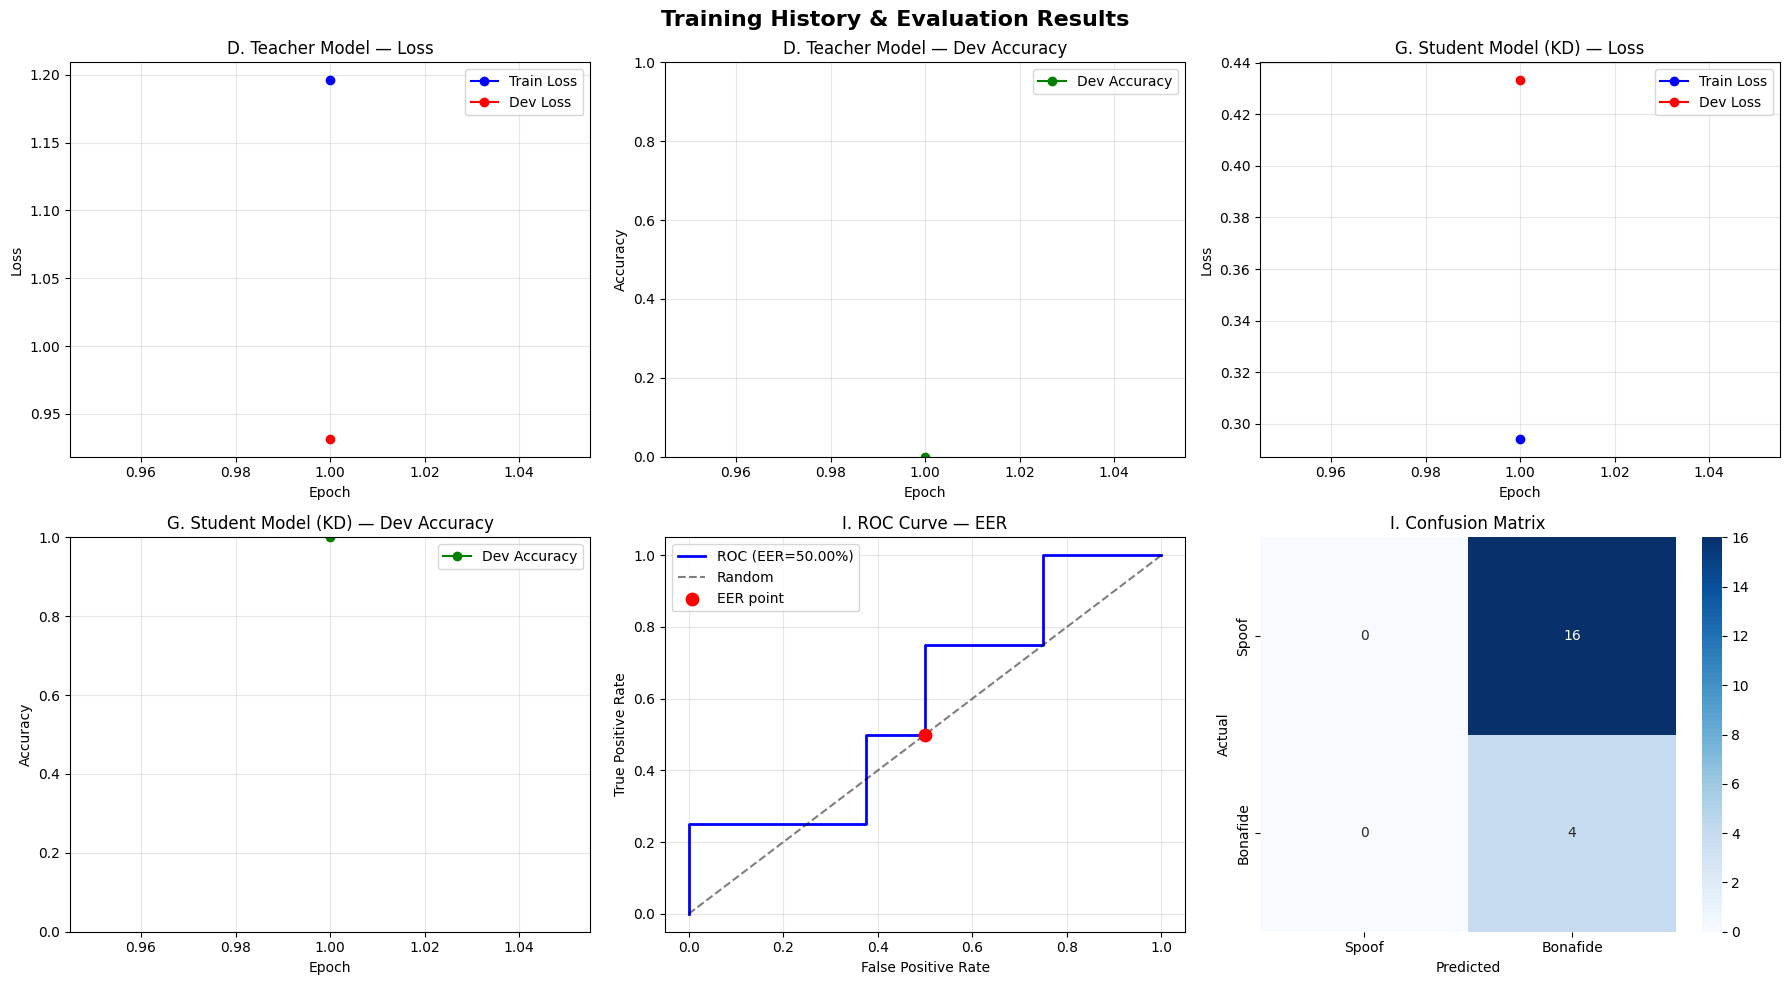

Graphs saved → models/training_results.png


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Training History & Evaluation Results', fontsize=16, fontweight='bold')

epochs_t = range(1, TEACHER_EPOCHS + 1)
epochs_s = range(1, STUDENT_EPOCHS + 1)

# ── Plot 1: Teacher Loss ──────────────────────────────────────────────────────
axes[0, 0].plot(epochs_t, teacher_history['train_loss'], 'b-o', label='Train Loss')
axes[0, 0].plot(epochs_t, teacher_history['dev_loss'],   'r-o', label='Dev Loss')
axes[0, 0].set_title('D. Teacher Model — Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# ── Plot 2: Teacher Accuracy ──────────────────────────────────────────────────
axes[0, 1].plot(epochs_t, teacher_history['dev_acc'], 'g-o', label='Dev Accuracy')
axes[0, 1].set_title('D. Teacher Model — Dev Accuracy')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_ylim(0, 1)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# ── Plot 3: Student Loss ──────────────────────────────────────────────────────
axes[0, 2].plot(epochs_s, student_history['train_loss'], 'b-o', label='Train Loss')
axes[0, 2].plot(epochs_s, student_history['dev_loss'],   'r-o', label='Dev Loss')
axes[0, 2].set_title('G. Student Model (KD) — Loss')
axes[0, 2].set_xlabel('Epoch')
axes[0, 2].set_ylabel('Loss')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# ── Plot 4: Student Accuracy ──────────────────────────────────────────────────
axes[1, 0].plot(epochs_s, student_history['dev_acc'], 'g-o', label='Dev Accuracy')
axes[1, 0].set_title('G. Student Model (KD) — Dev Accuracy')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].set_ylim(0, 1)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# ── Plot 5: ROC Curve with EER ────────────────────────────────────────────────
axes[1, 1].plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC (EER={eer:.2f}%)')
axes[1, 1].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
axes[1, 1].scatter([eer/100], [1 - eer/100], color='red', zorder=5, s=80, label='EER point')
axes[1, 1].set_title('I. ROC Curve — EER')
axes[1, 1].set_xlabel('False Positive Rate')
axes[1, 1].set_ylabel('True Positive Rate')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# ── Plot 6: Confusion Matrix ──────────────────────────────────────────────────
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 2],
            xticklabels=['Spoof', 'Bonafide'],
            yticklabels=['Spoof', 'Bonafide'])
axes[1, 2].set_title('I. Confusion Matrix')
axes[1, 2].set_xlabel('Predicted')
axes[1, 2].set_ylabel('Actual')

plt.tight_layout()
plt.savefig(str(MODEL_DIR / 'training_results.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Graphs saved → models/training_results.png')

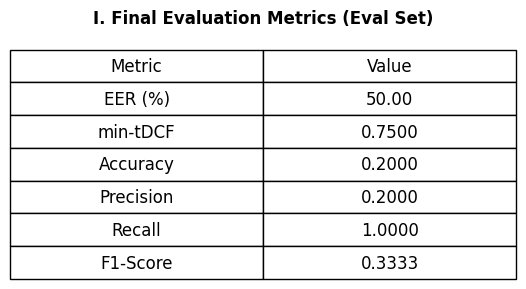

In [ ]:
# ── Final Metrics Summary ─────────────────────────────────────────────────────
metrics = {
    'EER (%)' : f'{eer:.2f}',
    'min-tDCF': f'{min_tdcf:.4f}',
    'Accuracy': f'{accuracy:.4f}',
    'Precision': f'{precision:.4f}',
    'Recall'  : f'{recall:.4f}',
    'F1-Score': f'{f1:.4f}'
}

fig, ax = plt.subplots(figsize=(6, 3))
ax.axis('off')
table_data = [[k, v] for k, v in metrics.items()]
table = ax.table(cellText=table_data, colLabels=['Metric', 'Value'],
                 cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.5, 2)
plt.title('I. Final Evaluation Metrics (Eval Set)', fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(str(MODEL_DIR / 'eval_metrics_table.png'), dpi=150, bbox_inches='tight')
plt.show()